<a href="https://colab.research.google.com/github/zish-s/IPL-EDA-Insights/blob/main/IPL_data_analysis_and_insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
path_deliveries = "/content/drive/MyDrive/datasets/deliveries.csv"
path_matches = "/content/drive/MyDrive/datasets/matches.csv"

In [35]:
matches = pd.read_csv(path_matches)
matches.head(100)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,392220,2009,Kimberley,2009-05-11,League,DR Smith,De Beers Diamond Oval,Deccan Chargers,Rajasthan Royals,Deccan Chargers,bat,Deccan Chargers,runs,53.0,167.0,20.0,N,NaN,GAV Baxter,HDPK Dharmasena
96,392221,2009,Centurion,2009-05-12,League,LRPL Taylor,SuperSport Park,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,6.0,174.0,20.0,N,NaN,M Erasmus,SS Hazare
97,392222,2009,Centurion,2009-05-12,League,Harbhajan Singh,SuperSport Park,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,bat,Mumbai Indians,wickets,8.0,120.0,20.0,N,NaN,SS Hazare,RE Koertzen
98,392223,2009,Durban,2009-05-13,League,R Bhatia,Kingsmead,Deccan Chargers,Delhi Daredevils,Deccan Chargers,field,Delhi Daredevils,runs,12.0,174.0,20.0,N,NaN,DJ Harper,SL Shastri


In [36]:
df = pd.read_csv(path_deliveries)
df.head(20)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
5,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,6,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
6,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,7,BB McCullum,P Kumar,SC Ganguly,0,1,1,legbyes,0,NaN,NaN,NaN
7,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,1,BB McCullum,Z Khan,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
8,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,2,BB McCullum,Z Khan,SC Ganguly,4,0,4,NaN,0,NaN,NaN,NaN
9,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,3,BB McCullum,Z Khan,SC Ganguly,4,0,4,NaN,0,NaN,NaN,NaN


In [37]:
df.shape  #(a,b) a rows, b columns

(260920, 17)

In [38]:
matches.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


#Data Cleaning & Filtering

In [39]:
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [40]:
matches['team1'].unique()

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [41]:
matches['season'].unique()

array(['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022',
       '2023', '2024'], dtype=object)

In [42]:
#rename teams
team_name_correction = {
    'Delhi Daredevils'        : 'Delhi Capitals',  #old --> new
    'Kings XI Punjab'         : 'Punjab Kings',
    'Rising Pune Supergiants'  : 'Rising Pune Supergiant',
    'Pune Warriors'           : 'Rising Pune Supergiant',
    'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru',
}

#gujarat lions played temporarily during 2016-17 season & gujarat titans has been active from 22-present

In [43]:
matches['team1'] = matches['team1'].replace(team_name_correction)
matches['team2'] = matches['team2'].replace(team_name_correction)

matches['team1'].nunique()
matches['team2'].nunique()

14

In [44]:
for col in ['team1', 'team2', 'toss_winner', 'winner']:
  matches[col] = matches[col].replace(team_name_correction)

In [45]:
#find out the still active teams and then figure out the inconsistencies
#such as players who didn't play in a specific season, teams who were banned,

active_teams = matches[matches['season']=='2024']['team1'].unique()
active_teams #teams which were active latest in 2024

array(['Royal Challengers Bengaluru', 'Delhi Capitals',
       'Kolkata Knight Riders', 'Rajasthan Royals', 'Gujarat Titans',
       'Punjab Kings', 'Chennai Super Kings', 'Sunrisers Hyderabad',
       'Lucknow Super Giants', 'Mumbai Indians'], dtype=object)

In [46]:
#create filtered dataframes

matches_active = matches[matches['team1'].isin(active_teams) & matches['team2'].isin(active_teams)]
matches_active

#NA winner rows
matches_active = matches_active[matches_active['winner'] != 'NA']
matches_active

#ties, no results
matches_active = matches_active[matches_active['result'] != 'tie']
matches_active

#CSK & RR were suspended for two years (the 2016 and 2017 seasons)
matches_f = matches_active[~matches_active['season'].isin(['2016','2017'])].copy()
matches_f   #cleaned up dataframe

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
5,335987,2007/08,Jaipur,2008-04-21,League,SR Watson,Sawai Mansingh Stadium,Rajasthan Royals,Punjab Kings,Punjab Kings,bat,Rajasthan Royals,wickets,6.0,167.0,20.0,N,NaN,Aleem Dar,RB Tiffin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma


In [47]:
# Show every team and which seasons they appeared in
for team in active_teams:
  print(team)
  print(matches[(matches['team1'] == team) | (matches['team2'] == team)]['season'].unique())

Royal Challengers Bengaluru
['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018' '2019' '2020/21' '2021' '2022' '2023' '2024']
Delhi Capitals
['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018' '2019' '2020/21' '2021' '2022' '2023' '2024']
Kolkata Knight Riders
['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018' '2019' '2020/21' '2021' '2022' '2023' '2024']
Rajasthan Royals
['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2018'
 '2019' '2020/21' '2021' '2022' '2023' '2024']
Gujarat Titans
['2022' '2023' '2024']
Punjab Kings
['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018' '2019' '2020/21' '2021' '2022' '2023' '2024']
Chennai Super Kings
['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2018'
 '2019' '2020/21' '2021' '2022' '2023' '2024']
Sunrisers Hyderabad
['2013' '2014' '2015' '2016' '2017' '2018' '2019' '2020/21' '2021' '2

#Data Analysing
Analyze trends in IPL to understand how the game has evolved over time

<Axes: xlabel='winner'>

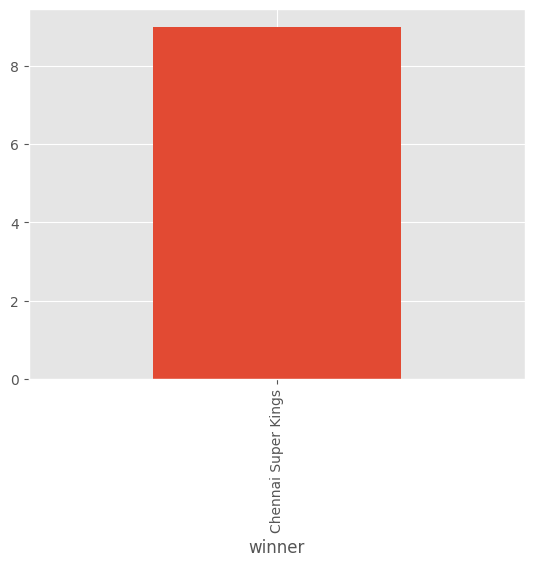

In [48]:
MS_Dhoni = matches_f[(matches_f['player_of_match'] == 'MS Dhoni') & (matches_f['season'].str[:4].astype(int) <= 2016)]  #
winner_team = MS_Dhoni['winner'].value_counts().plot(kind = "bar")
winner_team
#when ms dhoni was player of match over all the years which team won the most and how many times.

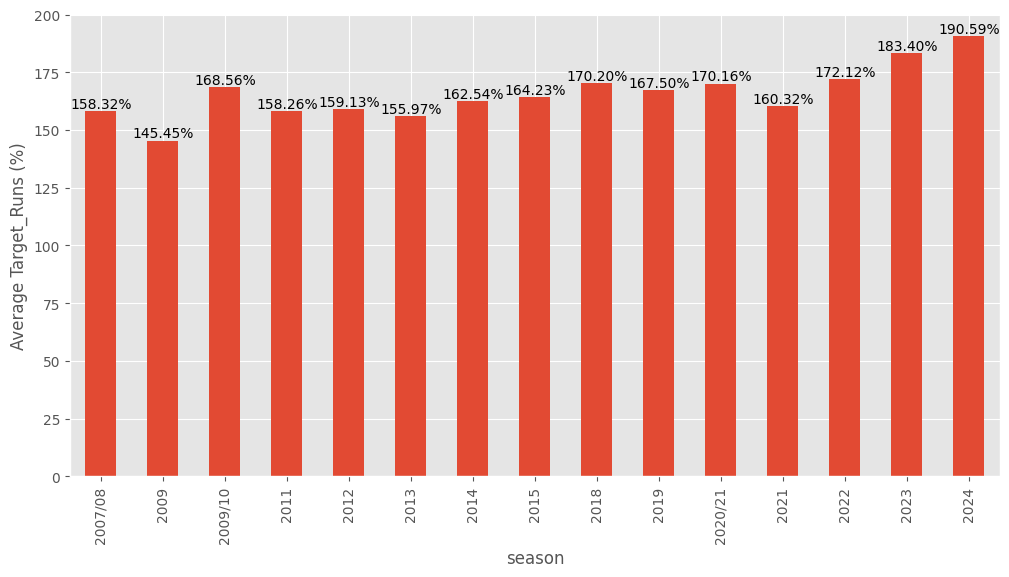

In [49]:
#is it becoming easier to score runs over the years?
#average runs over the seasons
plt.figure(figsize=(12,6))

avg_runs = matches_f.groupby('season')['target_runs'].mean().plot(kind='bar')

for p in avg_runs.patches:                       #p is one bar, patches mean all the bars in graph
    avg_runs.annotate(f"{p.get_height():.2f}%",  #get the height of the graph, convert into float and a %sign
                (p.get_x() + p.get_width()/2, p.get_height()), #where the label appears
    #start from beginning,  keep it in middle, keep @ top of bar
                ha='center', va='bottom')

plt.ylabel("Average Target_Runs (%)")
plt.show()

In [50]:
deliveries = pd.read_csv(path_deliveries)

In [51]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

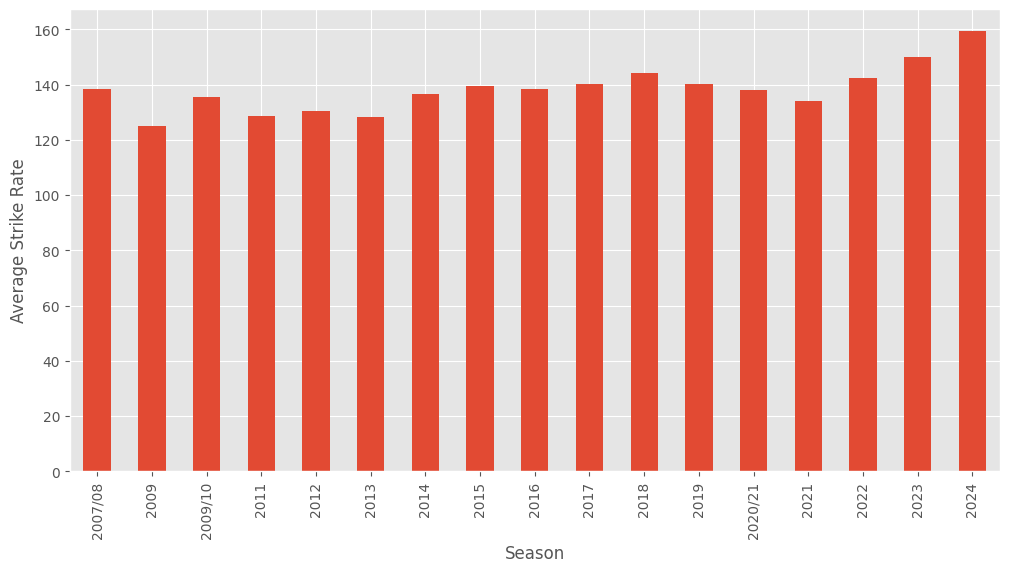

In [52]:
# Has strike rate increased over the years/seasons?
# Strike Rate = (Runs Scored / Balls Faced) × 100

# Merge files to get season + matchID in deliveries.csv
deliveries_replace_with_season = pd.merge(deliveries, matches[['id', 'season']], left_on='match_id', right_on='id',
                                          how='left')  #Keep all rows from deliveries, even if no match is found

runs = deliveries_replace_with_season.groupby('season')['total_runs'].sum()
legal_balls = deliveries_replace_with_season[~deliveries_replace_with_season['extras_type'].isin(['wides', 'noballs'])].groupby('season').size()

strike_rate = (runs / legal_balls) * 100

# Plot the strike rate over the years
plt.figure(figsize=(12,6))
strike_rate.plot(kind='bar')
plt.xlabel('Season')
plt.ylabel('Average Strike Rate')

plt.show()

In [75]:
#how likely a player with high avg_run and avg_strike_rate is to be pom
deliveries_pom = pd.merge(deliveries_replace_with_season, matches[['id', 'player_of_match']], left_on='match_id', right_on='id', how='left')

# Calculate runs and 'balls faced' by each player per season
player_season_stats = deliveries_pom.groupby(['season', 'batter']).agg(
    total_runs_scored=('batsman_runs', 'sum'),
    balls_faced=('ball', lambda x: x[~deliveries_pom.loc[x.index, 'extras_type'].isin(['wides', 'noballs'])].count())
).reset_index()

# Calculate strike rate
player_season_stats['strike_rate'] = (player_season_stats['total_runs_scored'] / player_season_stats['balls_faced']) * 100

player_season_stats = player_season_stats[player_season_stats['total_runs_scored'] > 0]
player_season_stats.dropna(subset=['strike_rate'], inplace=True) # Drop rows where strike_rate is NaN and remove 0 runs too

# Count how many times a player became pom
pom_counts = matches['player_of_match'].value_counts().reset_index()
pom_counts.columns = ['batter', 'pom_awards']

# Merge player season stats with player of the match counts
# We'll merge a player's overall POM awards to their season-wise performance and create a new dataframe
player_performance_with_pom = pd.merge(
    player_season_stats, pom_counts, on='batter', how='left')

player_performance_with_pom['pom_awards'] = player_performance_with_pom['pom_awards'].fillna(0).astype(int)

df = player_performance_with_pom.groupby('batter').agg({
    "total_runs_scored": "sum",
    "balls_faced": "sum",
    "strike_rate": "mean",
    "pom_awards": "sum" })
df.sort_values(by=["total_runs_scored"], ascending=[False], inplace=True)
df.head()

,total_runs_scored,balls_faced,strike_rate,pom_awards
batter,,,,
V Kohli,8014,6051,129.412327,306
S Dhawan,6769,5304,124.992046,204
RG Sharma,6630,5039,131.536582,323
DA Warner,6567,4682,138.697061,270
SK Raina,5536,4025,136.702565,182


In [76]:
df.sort_values(by=["strike_rate"], ascending=[False], inplace=True)
df.head()

,total_runs_scored,balls_faced,strike_rate,pom_awards
batter,,,,
BA Bhatt,6,2,300.000000,1
L Wood,9,3,300.000000,0
PN Mankad,97,72,265.492958,2
B Stanlake,5,2,250.000000,1
RV Gomez,50,51,246.000000,0


'player with most strike rate is BA Bhatt with an avg of 300 strike rate and total runs scored to be 6. \nhave recieved 1 pom award\n\nplayer with most runs is Virat Kohli with 8014 runs scored and 306 pom awards'

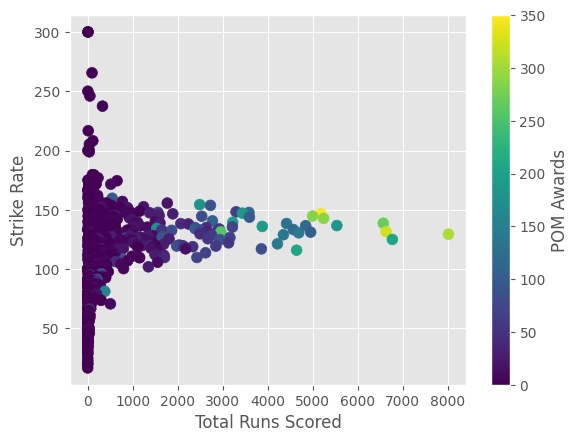

In [77]:
plt.scatter(
    df["total_runs_scored"],
    df["strike_rate"],
    c=df["pom_awards"],
    cmap="viridis",
    s=60
)

plt.colorbar(label="POM Awards")
plt.xlabel("Total Runs Scored")
plt.ylabel("Strike Rate")

'''player with most strike rate is BA Bhatt with an avg of 300 strike rate and total runs scored to be 6.
have recieved 1 pom award

player with most runs is Virat Kohli with 8014 runs scored and 306 pom awards'''



In [ ]:
#do teams win more when batting first or bowling?



In [ ]:
#which stadiums are more highscoring for batters and bowlers

In [ ]:
#does venue/stadium affect the match outcome

In [ ]:
matches_f[matches_f['season'] == '2007/08']['venue'].unique()

In [ ]:
plt.figure(figsize=(12,6))
most_wins = (matches['winner'].value_counts(normalize=True) * 100).plot(kind='bar')

for p in most_wins.patches:                       #p is one bar, patches mean all the bars in graph
    most_wins.annotate(f"{p.get_height():.1f}%",  #get the height of the graph, convert into float and a %sign
                (p.get_x() + p.get_width()/2, p.get_height()), #where the label appears
    #start from beginning,  keep it in middle, keep @ top of bar
                ha='center', va='bottom')

plt.ylabel("Percentage (%)")
plt.show()

In [ ]:
#Does winning the toss help win the match?
toss_win = matches.groupby('winner')['toss_winner'].value_counts().sort_values(ascending = False)

In [ ]:
toss_win.head(10).plot(kind='bar')